In [1]:
import numpy as np
import matplotlib.pyplot as plt
import string
import os

plt.rcParams.update(
    {
        "font.size": 11,  # base font size (tick labels)
        "axes.labelsize": 13,  # axis labels
        "axes.titlesize": 13,
        "legend.fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "figure.dpi": 300,
    }
)

import jax.numpy as jnp
import jax

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_device", jax.devices("cpu")[0])

# Import your optimization and plotting utilities
from optimization_core import (
    scaled_spdc_jsa_vectorized,
    penalty_norm_relaxation_box_grad_desc,
    load_results,
    to_complex,
)

In [ ]:
# ---------------------------------------------------------
# 1. Experiment parameters
# ---------------------------------------------------------

# # Sweep parameters
n_steps = 30  # Number of steps in the sweep
# taup=jnp.linspace(-0.49, 0.99 , n_steps) #b is analogous to the correlation coefficients in the correlation matrix

# Dispersion parameters
ldelk01 = 0  # Phase mismatch at the central frequencies
tau11 = 0  # Group-velocity matching
taup1 = jnp.linspace(
    0, 9, n_steps
)  # We can also sweep over taup1, which is the parameter that controls the pump bandwidth. This allows us to explore different regimes of pump bandwidth in relation to the phase-matching function.
taup = taup1[taup1 < 7.2]
tauf1 = 1.5  # \beta_F >> \beta_P
T0 = tauf1 / jnp.sqrt(jnp.pi)  # Pump bandwidth
T01 = 0  # Ultrafast pump approximation

# chunks = jnp.array_split(taup, 12)
# Compute chunk boundaries
n_chunks = 15
indices = jnp.linspace(0, n_steps, n_chunks + 1, dtype=int)

chunks = [taup[indices[i] : indices[i + 1]] for i in range(n_chunks)]

# Geometrical parameters
n_res = 10  # Number of points inside the bandwidth of the phase-matching function in the frequency grid nxnxnxnxn
d = 5  # Dimensionality of the problem

# Spectral resolution
sigmapm = (
    jnp.sqrt(jnp.pi) / tauf1
)  # Approximate HWHM of the phase-matching function, measured in terms of the sinc's main lobe width
delw = (
    sigmapm / n_res
)  # The spectral resolution is defined such that a minimum of n discrete points are sampled within each frequency vector over the bandwidth of the phase-matching function, regardless of the specific width of the evaluation function.

# Spectral window
domg = (
    2.5 * sigmapm
)  # We set the half-width of the frequency window wide enough to sample correctly both the jsa and reduced density matrix
omf = jnp.arange(-domg, domg, delw)
n = omf.size
print(
    n
)  # Note: Always check the frequency vector size, because later we are going to build a 5D grid with it, which greatly affects  the memory usage.

# Create N‑dimensional meshgrid
grid = jnp.meshgrid(*([omf] * d), indexing="ij")

50


In [3]:
def T_vv(T, v):
    """Compute T(v,v,v,v) -> vector of shape (n,)."""
    return jnp.einsum("ijklm,j,k,l,m->i", T, v, v, v, v)


def f_val(T, v):
    """Form f(v) = T(v,v,v,v,v)."""
    return jnp.einsum("ijklm,i,j,k,l,m->", T, v, v, v, v, v)


def residual_norm(T, v):
    """Compute || T(v,v,v,v) - f(v) v || (should be ~0 for eigenvector)."""
    v = v / jnp.linalg.norm(v)
    vt = T_vv(T, v)
    f = f_val(T, v)
    return jnp.linalg.norm(vt - f * v)

In [4]:
residual_list = []
max_eigenvalue_list = []
overlap_list = []

In [5]:
for i, taup_value in enumerate(taup):
    # ---------------------------------------------------------
    # 1. Export data
    # ---------------------------------------------------------
    filename = f"eigen_eval_results_hopdc_{d}D_20260621_taup_{taup_value:.2f}_tauf_{tauf1:.2f}.pkl"
    if os.path.exists("results_data/" + filename):
        df, _, _ = load_results(filename)
        v = to_complex(df["optim_lo"])
        v = v / jnp.linalg.norm(v)
        f_v = df["eta"]

        print("Building JSA grid...")
        jsa = scaled_spdc_jsa_vectorized(
            ldelk0=ldelk01, tau1=tau11, taup=taup_value, tauf=tauf1, T0=T01
        )  # Returns a callable function that evaluates the JSA on a point or a grid.
        jsa_data = jsa(
            *grid
        )  # Evaluate the JSA on the grid. This is the most memory intensive step, as it creates a large tensor of size (n,n,n) in this case. Always check the size of the grid and the resulting tensor to avoid memory issues.
        jsa_data = jsa_data / jnp.linalg.norm(jsa_data)  # Normalize the JSA data.

        f = f_val(jsa_data, v)
        res = residual_norm(jsa_data, v)

        residual_list.append(res)
        max_eigenvalue_list.append(f)
        overlap_list.append(f_v)

residuals = np.array(residual_list)
max_eigenvalues = np.array(max_eigenvalue_list)
overlaps = np.array(overlap_list)

Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...
Building JSA grid...


In [6]:
np.savez(
    f"residuals_eigen_cond_{d}D.npz",
    taup=taup,
    tauf=tauf1,
    residuals=residuals,
    max_eigenvalues=max_eigenvalues,
    overlaps=overlaps,
)

In [7]:
# data=np.load(f'residuals_eigen_cond_{d}D.npz')
# taup=data['taup']
# tauf=data['tauf']
# residuals=data['residual']
# max_eigenvalues=data['max_eigenvalues']
# overlaps=data['overlaps']

In [8]:
print(taup.shape)
print(residuals.shape)

(24,)
(24,)


/home/gisell/miniconda3/envs/tensor_lo_optim/lib/python3.14/site-packages/matplotlib/cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/gisell/miniconda3/envs/tensor_lo_optim/lib/python3.14/site-packages/matplotlib/cbook.py:1407: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


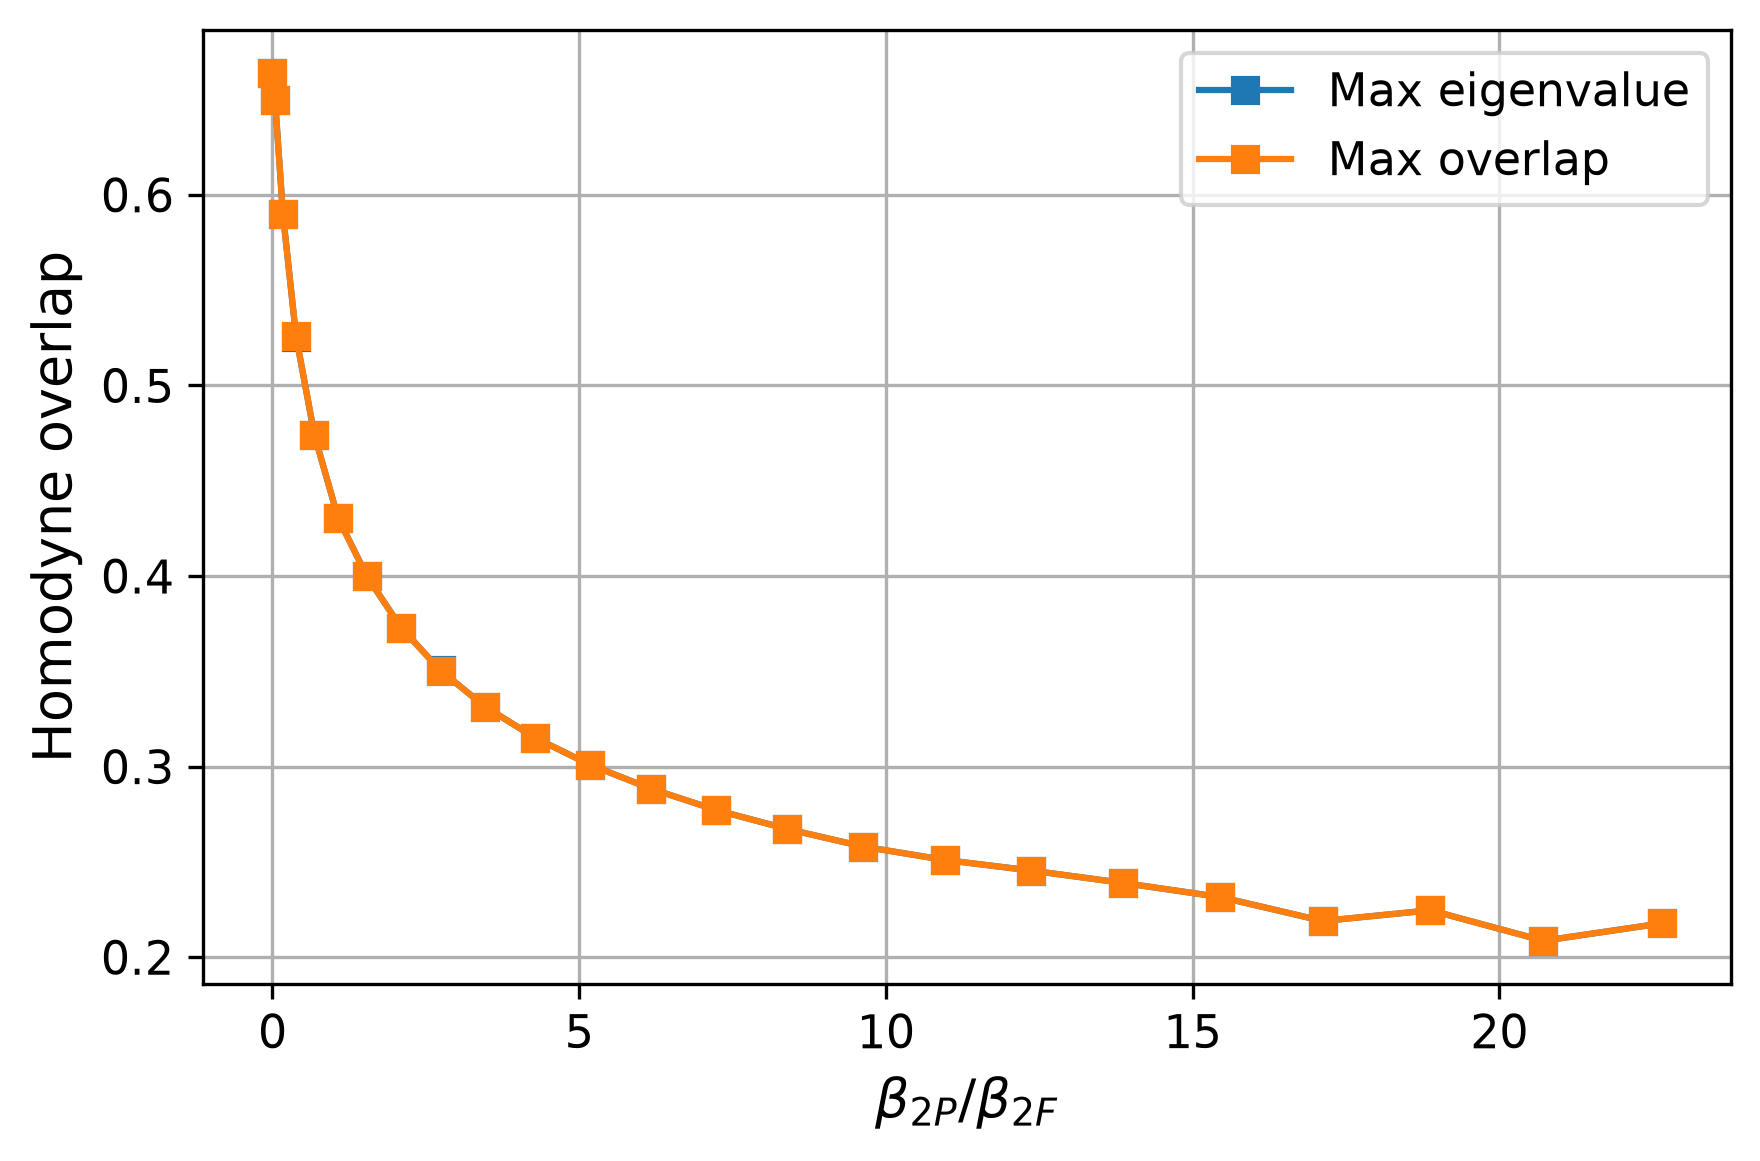

In [9]:
plt.figure(figsize=(6, 4))
plt.plot(
    (taup ** 2 / tauf1**2), max_eigenvalues, "s-", label="Max eigenvalue"
)
plt.plot((taup ** 2 / tauf1**2), overlaps, "s-", label="Max overlap")
plt.xlabel(r"$\beta_{2P}/\beta_{2F}$")
plt.ylabel("Homodyne overlap")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'r_overlap_{d}D.pdf', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2416007/2658238604.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


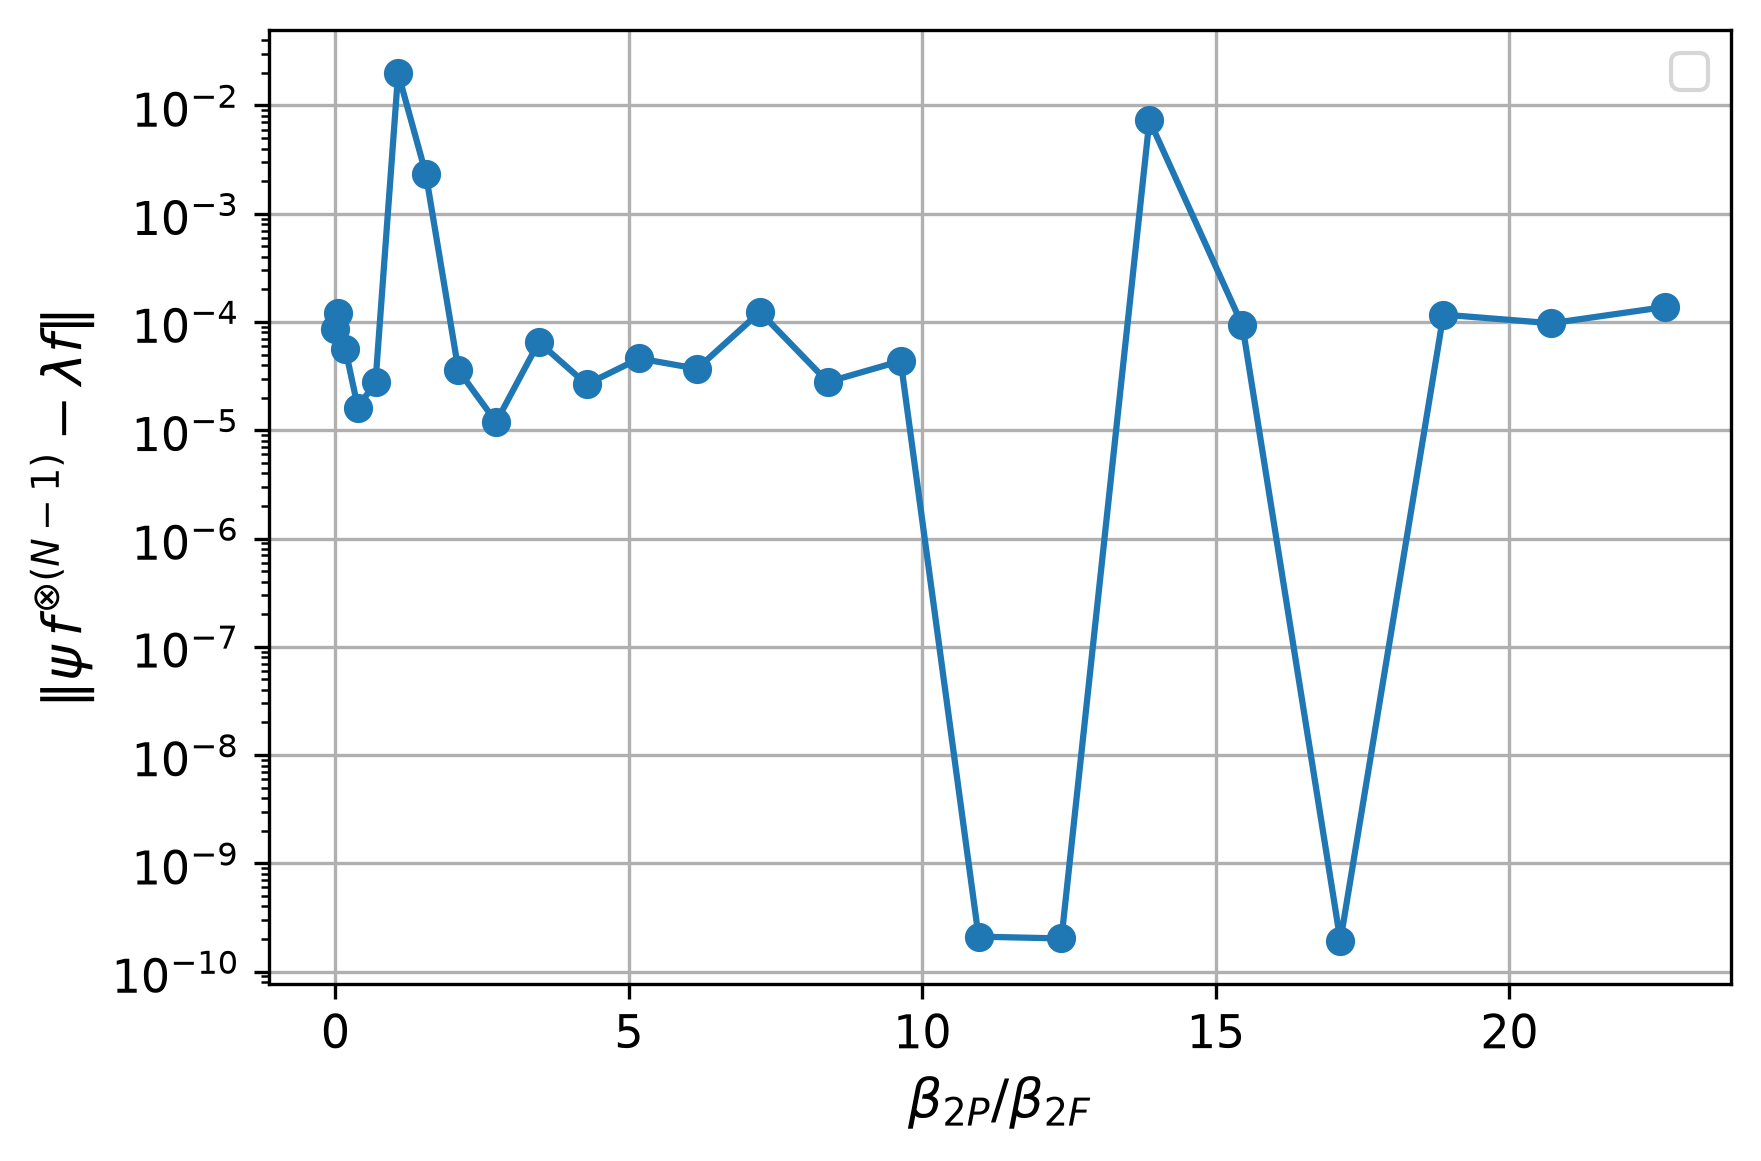

In [10]:
# --- Plot comparison ---
plt.figure(figsize=(6, 4))
plt.semilogy((taup ** 2 / tauf1**2), residuals, "o-")
plt.xlabel(r"$\beta_{2P}/\beta_{2F}$")
plt.ylabel(r"$\|\psi\,f^{\otimes (N-1)} - \lambda f\|$")
plt.legend()
plt.grid(True)
plt.tight_layout()
# plt.savefig(f'r_overlap_{d}D.pdf', dpi=300, bbox_inches='tight')
plt.show()